In [1]:
# --- 1. Imports ---
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc
)
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier

In [2]:
# 1. Load dataset
# wdbc.data does not have headers, so we define them
columns = ["ID", "Diagnosis"] + [f"feature_{i}" for i in range(1, 31)]
data = pd.read_csv("wdbc.data", header=None, names=columns)

In [3]:
# 2. Prepare features and target
X = data.drop(["ID", "Diagnosis"], axis=1)
y = data["Diagnosis"].map({"M": 1, "B": 0})  # Malignant=1, Benign=0

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [5]:
# --- 4. Find optimal n_components by explained variance ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

pca_full = PCA().fit(X_scaled)
cumulative_var = np.cumsum(pca_full.explained_variance_ratio_)
n_components_opt = np.argmax(cumulative_var >= 0.95) + 1  # 95% variance
print(f"Selected n_components = {n_components_opt} (95% variance preserved)")

Selected n_components = 10 (95% variance preserved)


In [6]:
# --- 5. Pipeline with fixed PCA ---
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=n_components_opt)),
    ("clf", XGBClassifier(eval_metric="logloss", random_state=42))
])

In [7]:
# --- 6. Hyperparameter grid (only XGBoost params) ---
param_grid = {
    "clf__n_estimators": [50, 100, 200],
    "clf__learning_rate": [0.01, 0.1, 0.2],
    "clf__max_depth": [3, 5, 7],
    "clf__gamma": [0, 0.1, 0.5],
    "clf__subsample": [0.8, 1.0],
    "clf__colsample_bytree": [0.8, 1.0],
}

In [8]:

# --- 7. GridSearchCV ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    refit=True,
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train, y_train)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'clf__colsample_bytree': [0.8, 1.0], 'clf__gamma': [0, 0.1, ...], 'clf__learning_rate': [0.01, 0.1, ...], 'clf__max_depth': [3, 5, ...], ...}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [10]:
# --- 8. Best model & top 5 hyperparameter trials ---
best_model = grid.best_estimator_
results = pd.DataFrame(grid.cv_results_)
top5 = results.sort_values(by="mean_test_score", ascending=False).head(5)

print("\nTop 5 Hyperparameter Trials (XGBoost with PCA):")
print(top5[[
    "param_clf__n_estimators",
    "param_clf__learning_rate",
    "param_clf__max_depth",
    "param_clf__gamma",
    "param_clf__subsample",
    "param_clf__colsample_bytree",
    "mean_test_score"
]].rename(columns={
    "param_clf__n_estimators": "n_estimators",
    "param_clf__learning_rate": "learning_rate",
    "param_clf__max_depth": "max_depth",
    "param_clf__gamma": "gamma",
    "param_clf__subsample": "subsample",
    "param_clf__colsample_bytree": "colsample_bytree",
    "mean_test_score": "Accuracy"
}))

print("\nBest Hyperparameters:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)


Top 5 Hyperparameter Trials (XGBoost with PCA):
     n_estimators  learning_rate  max_depth  gamma  subsample  \
197           200            0.1          7    0.0        1.0   
82            200            0.1          5    0.1        0.8   
38            100            0.2          3    0.0        0.8   
209           200            0.2          5    0.0        1.0   
208           200            0.2          5    0.0        0.8   

     colsample_bytree  Accuracy  
197               1.0  0.973626  
82                0.8  0.971429  
38                0.8  0.971429  
209               1.0  0.971429  
208               1.0  0.971429  

Best Hyperparameters: {'clf__colsample_bytree': 1.0, 'clf__gamma': 0, 'clf__learning_rate': 0.1, 'clf__max_depth': 7, 'clf__n_estimators': 200, 'clf__subsample': 1.0}
Best CV Accuracy: 0.9736263736263737


In [11]:
print("\nBest Hyperparameters:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)


Best Hyperparameters: {'clf__colsample_bytree': 1.0, 'clf__gamma': 0, 'clf__learning_rate': 0.1, 'clf__max_depth': 7, 'clf__n_estimators': 200, 'clf__subsample': 1.0}
Best CV Accuracy: 0.9736263736263737


In [13]:

# --- 9. Test Performance ---
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("\nTest Accuracy:", accuracy_score(y_test, y_pred))
print("Test F1 Score:", f1_score(y_test, y_pred))
print("Test Precision:", precision_score(y_test, y_pred))
print("Test Recall:", recall_score(y_test, y_pred))
print("Test ROC AUC:", roc_auc_score(y_test, y_pred))


Test Accuracy: 0.9736842105263158
Test F1 Score: 0.963855421686747
Test Precision: 0.975609756097561
Test Recall: 0.9523809523809523
Test ROC AUC: 0.9692460317460317


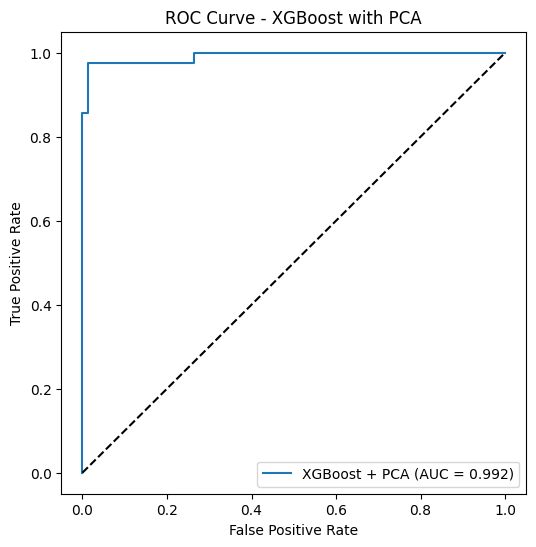

In [14]:
# --- 9. ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"XGBoost + PCA (AUC = {roc_auc:.3f})")
plt.plot([0,1],[0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost with PCA")
plt.legend()
plt.show()

/tmp/ipykernel_12029/2643072674.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp, y=feat_imp.index, palette="viridis")


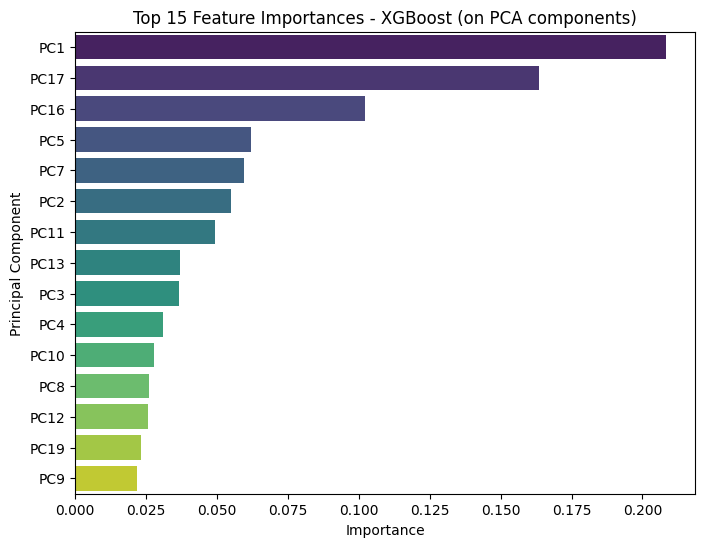

In [22]:
# --- 10. Feature Importances (XGBoost + PCA) ---
importances = best_model.named_steps["clf"].feature_importances_

# Number of components actually used
n_components = best_model.named_steps["pca"].n_components_

# Create names for PCA features
pca_features = [f"PC{i+1}" for i in range(n_components)]

feat_imp = pd.Series(importances, index=pca_features).sort_values(ascending=False)[:15]

plt.figure(figsize=(8,6))
sns.barplot(x=feat_imp, y=feat_imp.index, palette="viridis")
plt.title("Top 15 Feature Importances - XGBoost (on PCA components)")
plt.xlabel("Importance")
plt.ylabel("Principal Component")
plt.show()


In [15]:

# --- 11. 5-Fold Cross Validation Accuracy ---
cv_acc = cross_val_score(best_model, X_train, y_train, cv=cv, scoring="accuracy")
for i, acc in enumerate(cv_acc, 1):
    print(f"Fold {i} Accuracy: {acc:.4f}")
print(f"Average 5-Fold CV Accuracy: {cv_acc.mean():.4f}")


Fold 1 Accuracy: 0.9670
Fold 2 Accuracy: 0.9780
Fold 3 Accuracy: 0.9670
Fold 4 Accuracy: 0.9670
Fold 5 Accuracy: 0.9890
Average 5-Fold CV Accuracy: 0.9736


In [22]:
# --- PCA Cumulative Explained Variance Ratios (First 4 components) ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA().fit(X_scaled)

# Take first 4 explained variance ratios
explained_ratios = pca.explained_variance_ratio_[:40]

# Compute cumulative variance explained step by step
cumulative_ratios = np.cumsum(explained_ratios)

print("Cumulative Explained Variance (first 4 PCs):")
for i, cum in enumerate(cumulative_ratios, 1):
    print(f"PC1..PC{i}: {cum:.4f}")

Cumulative Explained Variance (first 4 PCs):
PC1..PC1: 0.4427
PC1..PC2: 0.6324
PC1..PC3: 0.7264
PC1..PC4: 0.7924
PC1..PC5: 0.8473
PC1..PC6: 0.8876
PC1..PC7: 0.9101
PC1..PC8: 0.9260
PC1..PC9: 0.9399
PC1..PC10: 0.9516
PC1..PC11: 0.9614
PC1..PC12: 0.9701
PC1..PC13: 0.9781
PC1..PC14: 0.9834
PC1..PC15: 0.9865
PC1..PC16: 0.9892
PC1..PC17: 0.9911
PC1..PC18: 0.9929
PC1..PC19: 0.9945
PC1..PC20: 0.9956
PC1..PC21: 0.9966
PC1..PC22: 0.9975
PC1..PC23: 0.9983
PC1..PC24: 0.9989
PC1..PC25: 0.9994
PC1..PC26: 0.9997
PC1..PC27: 0.9999
PC1..PC28: 1.0000
PC1..PC29: 1.0000
PC1..PC30: 1.0000
